# IDX Next-Day Price Direction Prediction
## Phase 1: Feature Engineering & Modeling Dataset Construction

**Sections 1–9**: Load cleaned data -> engineer features -> create target -> drop NaN -> export pre-split dataset.

Preventing leakage: All operations up to Section 9 are per-ticker or per-date and backward-looking only. 

## We left off week 1 (01_EDA_Cleaning.ipynb) with:
**Input:** `eren2222/complete-indonesia-stock-exchange-idx-2000-2024` from Kaggle, which contains JCI stock data from 2000-2024.

**Key findings from EDA:**
- OHLC columns correlated >0.95; raw prices introduce multicollinearity without signal
- Returns are fat-tailed (high kurtosis), slightly negative skew
- Target class balance: ~63% down days / ~37% up days
- Many instances of delisted stocks creating "flat" price action, this was handled by only taking stocks whose tickers are listed in the IDX website

**Sector selection:** Energy (87 tickers) + Technology (47 tickers). Contrasting dynamics: commodity-driven vs. growth/volatility. 4 suspended tickers removed, leaving 130.

**Data cleaning:**
- Forward-filled OHLCV gaps (limit=3) per ticker
- Removed zero-volume flat-price rows (likely non-trading days): 9,304 rows dropped
- Result: 95,932 rows, 0 missing values, 0 duplicates

**Output:** `Dataset/cleaned/energy.parquet` and `technology.parquet`

## This week (week 2):
### Data Preparation & Feature Engineering

**Principle:** Encode temporal context into a flat feature vector per row. The model sees one (ticker, day) at a time; all memory of the past must be explicit.

**Feature categories:**

- **Base derived (7):** daily_return, log_return, high_low_spread, close_open_gap, price_position, volume_change, log_volume
- **Lag features (30):** 5 base cols * lags [1,2,3,5,10,20]. Validated with ACF/PACF which indicated autocorrelation at short lags, PACF cutoff ~5-10
- **Rolling window (29):** 4 windows [5,10,20,50] * 7 stat types (price_vs_ma, volatility, volume_ratio, volume_std, momentum, dist_from_high, dist_from_low) + autocorr_20d
- **Cross-sectional (8):** sector_avg_return (ex-self), sector_return_dispersion, relative_strength, sector_pos_frac, sector_total_volume, rel_strength_ma5/20, sector_vol_regime
- **Calendar (3):** day_of_week, month, quarter

**Design constraints enforced:**
- Scale invariant features only (ratios, returns) for cross ticker comparability
- All groupby + shift/rolling operations per ticker; so no cross ticker leakage
- Cross sectional sector averages exclude self; no self comparison

**Validation:**
- Rolling MA overlay: `price_vs_ma20` matches manual Close/MA20-1 to 6 decimal places
- Lag shift check: correlation(`daily_return(t)`, `daily_return_lag1(t+1)`) = 1.0
- Target verification: all rows checked that t+1 matches its assigned class value
- Inf values (pct_change div-by-zero on AKRA, ITMG, RIGS): replaced with NaN, dropped in Section 8

**Output:** `Dataset/processed/energy.parquet` and `technology.parquet`. 77 features + target.

## Important Note:
This still has too many features, next IPYNB will attempt to find which features actually matter and prune the rest.

In [52]:
import os
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = os.path.join('Dataset', 'cleaned')
OUTPUT_DIR = os.path.join('Dataset', 'processed')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python: {sys.version.split()[0]}  |  Pandas: {pd.__version__}  |  NumPy: {np.__version__}")

Timestamp: 2026-05-26 21:36:14
Python: 3.13.13  |  Pandas: 3.0.1  |  NumPy: 2.4.3


---
## Section 1: Setup & Data Loading

In [53]:
energy = pd.read_parquet(os.path.join(DATA_DIR, 'energy.parquet'))
energy['sector'] = 'Energy'

technology = pd.read_parquet(os.path.join(DATA_DIR, 'technology.parquet'))
technology['sector'] = 'Technology'

df = pd.concat([energy, technology], ignore_index=True)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Total rows:     {len(df):,}")
print(f"Unique tickers: {df['Ticker'].nunique()}")
print(f"Date range:     {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nSector distribution:")
print(df['sector'].value_counts())
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nRows per ticker — min: {df.groupby('Ticker').size().min()}, "
      f"median: {df.groupby('Ticker').size().median():.0f}, "
      f"max: {df.groupby('Ticker').size().max()}")

Total rows:     95,932
Unique tickers: 130
Date range:     2020-01-02 to 2024-05-17

Sector distribution:
sector
Energy        66885
Technology    29047
Name: count, dtype: int64

Columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'sector']

Missing values:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
sector       0
dtype: int64

Rows per ticker — min: 21, median: 958, max: 1058


---
## Section 2: Base Derived Features

Per-ticker features: intraday dynamics and daily changes. All use Adj Close for returns and raw OHLC for intraday ratios (scale-invariant).

Scale invariant: A feature's value doesn't depend on the absolute price level of the stock, but instead uses ratios.

In [54]:
def add_base_features(df):
    """Add per-ticker derived features. All backward-looking by construction."""
    df = df.copy()

    g = df.groupby('Ticker')

    # returns - Adj Close avoids split/dividend halts
    df['daily_return'] = g['Adj Close'].pct_change()
    df['log_return'] = np.log(df['Adj Close'] / g['Adj Close'].shift(1))

    # intraday features (scale-invariant ratios-- think of this like normalization)
    df['high_low_spread'] = (df['High'] - df['Low']) / df['Close']
    df['close_open_gap'] = (df['Close'] - df['Open']) / df['Open']

    # price position within daily range (0 = low, 1 = high)
    hl_range = df['High'] - df['Low']
    df['price_position'] = np.where(
        hl_range > 0,
        (df['Close'] - df['Low']) / hl_range,
        0.5  # fill when High == Low (rare, flat day)
    )

    # volume
    df['volume_change'] = g['Volume'].pct_change()
    df['log_volume'] = np.log1p(df['Volume'])

    return df

In [55]:
df = add_base_features(df)

print("features added:")
base_cols = ['daily_return', 'log_return', 'high_low_spread',
             'close_open_gap', 'price_position', 'volume_change', 'log_volume']
print(df[base_cols].describe().round(4))

features added:
       daily_return  log_return  high_low_spread  close_open_gap  \
count    95802.0000  95802.0000       95932.0000      95932.0000   
mean         0.0007     -0.0001           0.0507             inf   
std          0.0430      0.0415           0.0480             NaN   
min         -0.3462     -0.4249           0.0000         -0.3824   
25%         -0.0159     -0.0160           0.0208         -0.0170   
50%          0.0000      0.0000           0.0390          0.0000   
75%          0.0105      0.0105           0.0672          0.0103   
max          0.5000      0.4055           0.7549             inf   

       price_position  volume_change  log_volume  
count      95932.0000     95802.0000  95932.0000  
mean           0.4597            inf     13.9356  
std            0.3241            NaN      3.5423  
min            0.0000        -1.0000      0.0000  
25%            0.1890        -0.4682     11.5396  
50%            0.5000        -0.0360     14.3107  
75%           

---
## Section 3: Lag Features

For each key derived feature, create lagged versions at [1, 2, 3, 5, 10, 20] trading days. `groupby('Ticker') + shift()` ensures no cross-ticker leakage.

### Definition: Lag features: 
The model can't look into the past on its own, it "sees" one row at a time as a flat vector; we need to encode past information as a feature to give the model learn relationships between $t_0, ..., t_n$ and $t_{n+1}$

In [56]:
LAG_COLS = ['daily_return', 'volume_change', 'high_low_spread',
            'close_open_gap', 'price_position']
LAG_DAYS = [1, 2, 3, 5, 10, 20]

lagged_features = []
for col in LAG_COLS:
    for lag in LAG_DAYS:
        name = f'{col}_lag{lag}'
        df[name] = df.groupby('Ticker')[col].shift(lag)
        lagged_features.append(name)

In [57]:
print(f"Lag features created: {len(lagged_features)}")
print(f"  Source columns: {LAG_COLS}")
print(f"  Lag windows:    {LAG_DAYS}")
print(f"  Total:          {len(LAG_COLS)} × {len(LAG_DAYS)} = {len(lagged_features)}")

Lag features created: 30
  Source columns: ['daily_return', 'volume_change', 'high_low_spread', 'close_open_gap', 'price_position']
  Lag windows:    [1, 2, 3, 5, 10, 20]
  Total:          5 × 6 = 30


---
### ACF & PACF: verify there is temporal structure worth modeling?

**ACF (Autocorrelation Function):** Correlation between `daily_return(t)` and `daily_return(t-k)`. A spike at lag k means today's return is correlated with the return k days ago, including chain effects through lags.

**PACF (Partial Autocorrelation Function):** Direct correlation after removing intermediate lags. A spike at lag k means lag k carries unique predictive signal beyond what lags $1, …,k-1$ already capture.

How to read plots:
- Bars past the blue band = statistically significant
- ACF decays slowly -> trend/momentum present. ACF near zero everywhere -> returns are close to white noise (hard to predict)
- PACF cuts off after lag N -> only ~N lags carry unique signal. If PACF cuts off at lag ~5, our lags 10–20 add diminishing returns, etc.

Plots: pooled sector-level ACF/PACF (avg return across all tickers per day) + one representative ticker.

Intermediate lag: intermediate lags are the time steps that sit between the current observation and the lag of interest. 

In [58]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Adra Prakoso\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


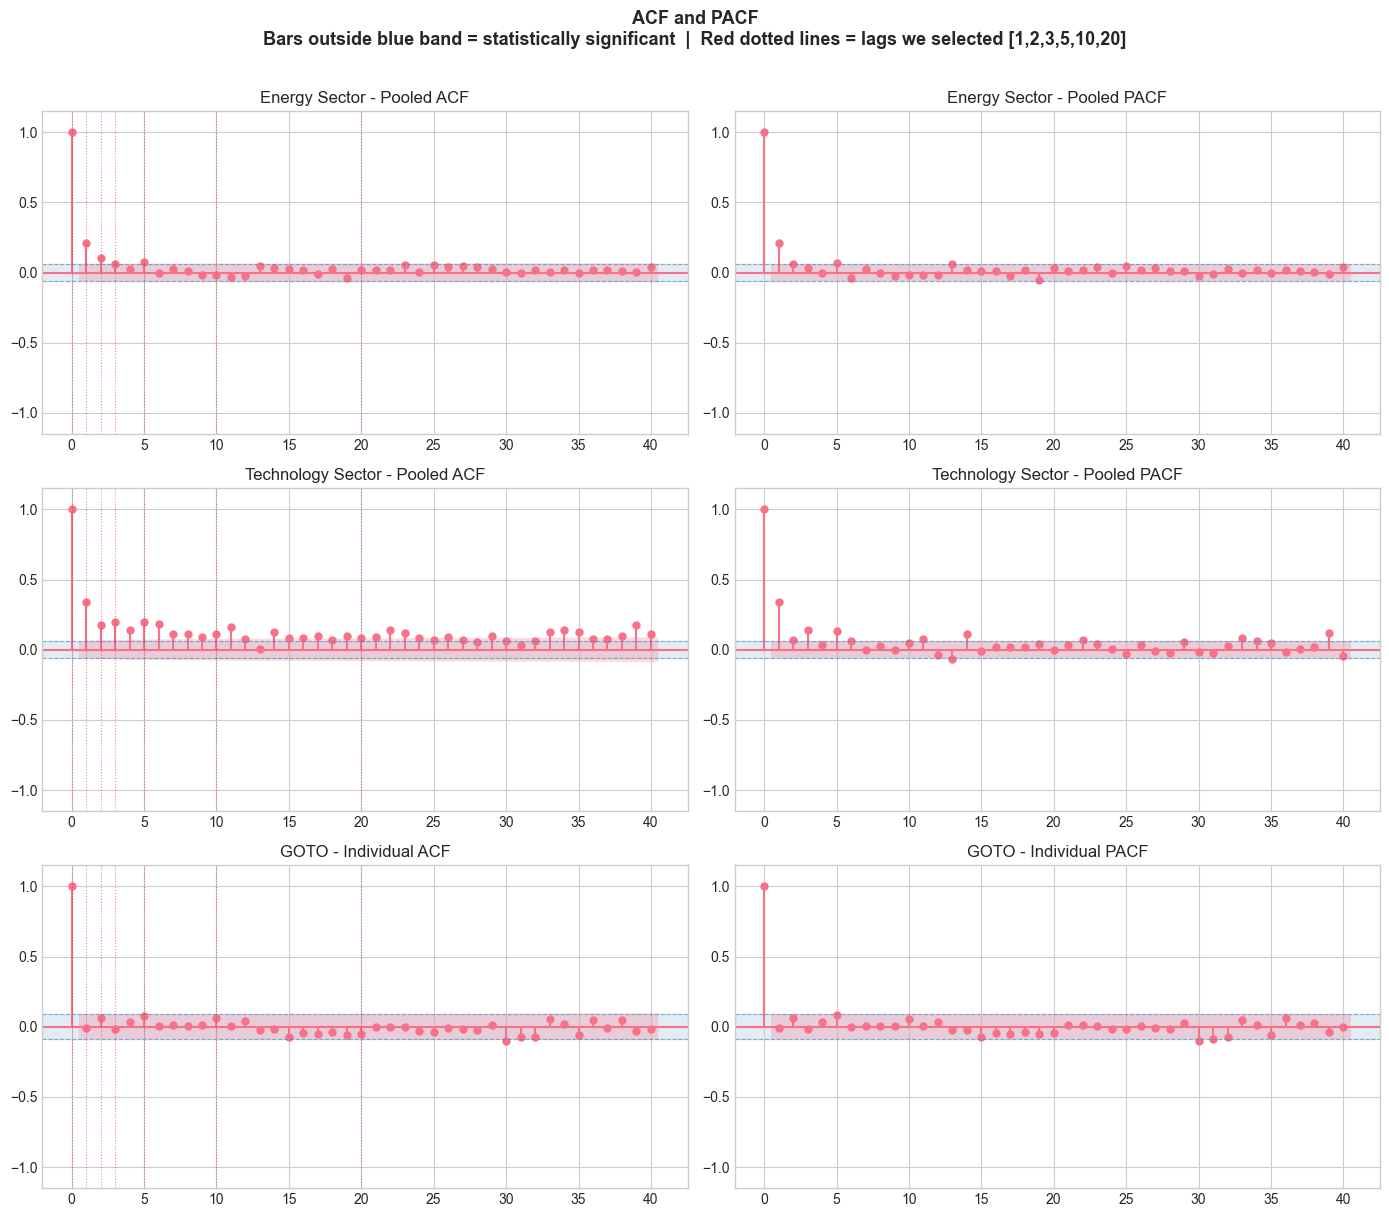


Energy pooled:
  Significant ACF lags (|r| > 0.05): [1, 2, 3, 5]
  Max |ACF|: 0.2082 at lag 1

Technology pooled:
  Significant ACF lags (|r| > 0.05): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20]
  Max |ACF|: 0.3368 at lag 1

GOTO individual:
  Significant ACF lags (|r| > 0.05): [2, 5, 10, 15, 17, 19, 20]
  Max |ACF|: 0.0776 at lag 5


In [59]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Confidence threshold for ~5%
def add_conf_band(ax, series, lags=40, alpha=0.05):
    n = len(series)
    # 1.96 approx for 95% CI
    z = 1.96
    bound = z / np.sqrt(n)
    ax.axhspan(-bound, bound, color='steelblue', alpha=0.15, zorder=0)
    ax.axhline(bound, color='steelblue', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(-bound, color='steelblue', linestyle='--', linewidth=0.8, alpha=0.6)

MAX_LAGS = 40 
sample_ticker = 'GOTO'

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Energy sector returns
energy_pooled = df[df['sector'] == 'Energy'].groupby('Date')['daily_return'].mean().dropna()
plot_acf(energy_pooled, lags=MAX_LAGS, ax=axes[0, 0], title='Energy Sector - Pooled ACF')
plot_pacf(energy_pooled, lags=MAX_LAGS, ax=axes[0, 1], title='Energy Sector - Pooled PACF', method='ywm')

# Technology sector returns
tech_pooled = df[df['sector'] == 'Technology'].groupby('Date')['daily_return'].mean().dropna()
plot_acf(tech_pooled, lags=MAX_LAGS, ax=axes[1, 0], title='Technology Sector - Pooled ACF')
plot_pacf(tech_pooled, lags=MAX_LAGS, ax=axes[1, 1], title='Technology Sector - Pooled PACF', method='ywm')

# Single representative ticker
ticker_returns = df[df['Ticker'] == sample_ticker]['daily_return'].dropna()
plot_acf(ticker_returns, lags=MAX_LAGS, ax=axes[2, 0], title=f'{sample_ticker} - Individual ACF')
plot_pacf(ticker_returns, lags=MAX_LAGS, ax=axes[2, 1], title=f'{sample_ticker} - Individual PACF', method='ywm')

add_conf_band(axes[0, 0], energy_pooled, lags=MAX_LAGS)
add_conf_band(axes[0, 1], energy_pooled, lags=MAX_LAGS)
add_conf_band(axes[1, 0], tech_pooled, lags=MAX_LAGS)
add_conf_band(axes[1, 1], tech_pooled, lags=MAX_LAGS)
add_conf_band(axes[2, 0], ticker_returns, lags=MAX_LAGS)
add_conf_band(axes[2, 1], ticker_returns, lags=MAX_LAGS)

for ax in axes.flat:
    ax.set_ylim(-1.15, 1.15)

# Chosen lag windows on each ACF plot
for ax in [axes[0, 0], axes[1, 0], axes[2, 0]]:
    for lag in [1, 2, 3, 5, 10, 20]:
        ax.axvline(x=lag, color='crimson', linestyle=':', linewidth=0.8, alpha=0.5)
    # legend entry for lag markers
    ax.axvline(x=0, color='crimson', linestyle=':', linewidth=0.8, alpha=0.5, label='Our lag windows')

plt.suptitle('ACF and PACF\n'
             'Bars outside blue band = statistically significant  |  '
             'Red dotted lines = lags we selected [1,2,3,5,10,20]',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

def summarize_acf(series, name, max_lag=20):
    acf_vals = [series.autocorr(lag=i) for i in range(1, max_lag + 1)]
    sig_lags = [i for i, v in enumerate(acf_vals, 1) if abs(v) > 0.05]
    print(f"\n{name}:")
    print(f"  Significant ACF lags (|r| > 0.05): {sig_lags if sig_lags else 'NONE : returns are near white noise'}")
    print(f"  Max |ACF|: {max(abs(v) for v in acf_vals):.4f} at lag {acf_vals.index(max(acf_vals, key=abs)) + 1}")

summarize_acf(energy_pooled, 'Energy pooled')
summarize_acf(tech_pooled, 'Technology pooled')
summarize_acf(ticker_returns, f'{sample_ticker} individual')

---
## Section 4: Rolling Window Statistics

Windows: [5, 10, 20, 50] trading days. All computed per-ticker with `groupby().rolling()`. These capture trend, volatility, volume regime, and momentum; statistical properties the LSTM can learn but which serve as strong baselines for classical models.

In [60]:
    df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,sector,daily_return,...,close_open_gap_lag3,close_open_gap_lag5,close_open_gap_lag10,close_open_gap_lag20,price_position_lag1,price_position_lag2,price_position_lag3,price_position_lag5,price_position_lag10,price_position_lag20
0,2020-01-13,ABMM,1300.0,1515.0,1300.0,1515.0,1214.466431,500.0,Energy,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-16,ABMM,1495.0,1495.0,1490.0,1490.0,1194.425781,1500.0,Energy,-0.016502,...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
2,2020-01-20,ABMM,1490.0,1490.0,1490.0,1490.0,1194.425781,6000.0,Energy,0.000000,...,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN
3,2020-01-23,ABMM,1475.0,1480.0,1470.0,1480.0,1186.409424,800.0,Energy,-0.006711,...,0.165385,NaN,NaN,NaN,0.500000,0.000000,1.000000,NaN,NaN,NaN
4,2020-01-28,ABMM,1450.0,1450.0,1450.0,1450.0,1162.360596,100.0,Energy,-0.020270,...,-0.003344,NaN,NaN,NaN,1.000000,0.500000,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95927,2024-05-13,ZYRX,149.0,149.0,144.0,146.0,146.000000,180100.0,Technology,-0.013514,...,-0.006803,-0.026667,-0.013423,-0.033333,1.000000,0.750000,0.857143,0.000000,0.500000,0.300000
95928,2024-05-14,ZYRX,146.0,146.0,142.0,146.0,146.000000,95800.0,Technology,0.000000,...,-0.006849,-0.013423,-0.020270,0.006944,0.400000,1.000000,0.750000,0.400000,0.000000,0.666667
95929,2024-05-15,ZYRX,143.0,146.0,135.0,140.0,140.000000,3749200.0,Technology,-0.041096,...,0.020690,-0.006803,0.013793,0.013605,1.000000,0.400000,1.000000,0.857143,0.400000,0.444444
95930,2024-05-16,ZYRX,141.0,141.0,138.0,139.0,139.000000,437800.0,Technology,-0.007143,...,-0.020134,-0.006849,-0.020000,0.000000,0.454545,1.000000,0.400000,0.750000,0.250000,1.000000


In [61]:
WINDOWS = [5, 10, 20, 50]

rolling_features = []

for ticker, group in df.groupby('Ticker'):
    idx = group.index
    group = group.sort_values('Date')

    for w in WINDOWS:
        roll = group.rolling(window=w, min_periods=max(w // 2, 2))

        # Trend - price relative to MA
        adj_close_ma = roll['Adj Close'].mean()
        df.loc[idx, f'price_vs_ma{w}'] = group['Adj Close'].values / adj_close_ma.values - 1
        # ^^ df.loc is pandas' label based indexer; selects rows and cols based by their labels not integer positions
        
        # realized vol over window
        ret_std = roll['daily_return'].std()
        df.loc[idx, f'volatility_{w}d'] = ret_std.values

        # current volume relative to rolling avg
        vol_ma = roll['Volume'].mean()
        df.loc[idx, f'volume_ratio_{w}d'] = group['Volume'].values / vol_ma.values
        vol_std = roll['Volume'].std()
        df.loc[idx, f'volume_std_{w}d'] = vol_std.values

        # rate of change over window
        roc = group['Adj Close'] / group['Adj Close'].shift(w) - 1
        df.loc[idx, f'momentum_{w}d'] = roc.values

        # distance from rolling high and low
        roll_high = roll['Close'].max()
        roll_low = roll['Close'].min()
        df.loc[idx, f'dist_from_high{w}'] = (group['Close'].values / roll_high.values - 1)
        df.loc[idx, f'dist_from_low{w}'] = (group['Close'].values / roll_low.values - 1)

    # autocorrelation over 20-day window (momentum/reversal signal)
    ret = group['daily_return']
    df.loc[idx, 'autocorr_20d'] = (
        ret.rolling(20, min_periods=10)
        .apply(lambda x: x.autocorr() if len(x) >= 5 else np.nan, raw=False)
        .values
    )

Autocorrelation: measures how correlated a time series is with a lagged version of itself. COmputed as 20 day rolling autocorrelation of daily return, use this as a reversal signal

In [62]:
# rolling feature names
rolling_features = (
    [f'price_vs_ma{w}' for w in WINDOWS]
    + [f'volatility_{w}d' for w in WINDOWS]
    + [f'volume_ratio_{w}d' for w in WINDOWS]
    + [f'volume_std_{w}d' for w in WINDOWS]
    + [f'momentum_{w}d' for w in WINDOWS]
    + [f'dist_from_high{w}' for w in WINDOWS]
    + [f'dist_from_low{w}' for w in WINDOWS]
    + ['autocorr_20d']
)

print(f"Rolling features created: {len(rolling_features)}")
print(f"  Windows: {WINDOWS}")
print(f"  Categories: price_vs_ma, volatility, volume_ratio, volume_std, "
      f"momentum, dist_from_high, dist_from_low, autocorr")

Rolling features created: 29
  Windows: [5, 10, 20, 50]
  Categories: price_vs_ma, volatility, volume_ratio, volume_std, momentum, dist_from_high, dist_from_low, autocorr


---
### Sanity Check: Price + Rolling MA Overlay (AI generated code)

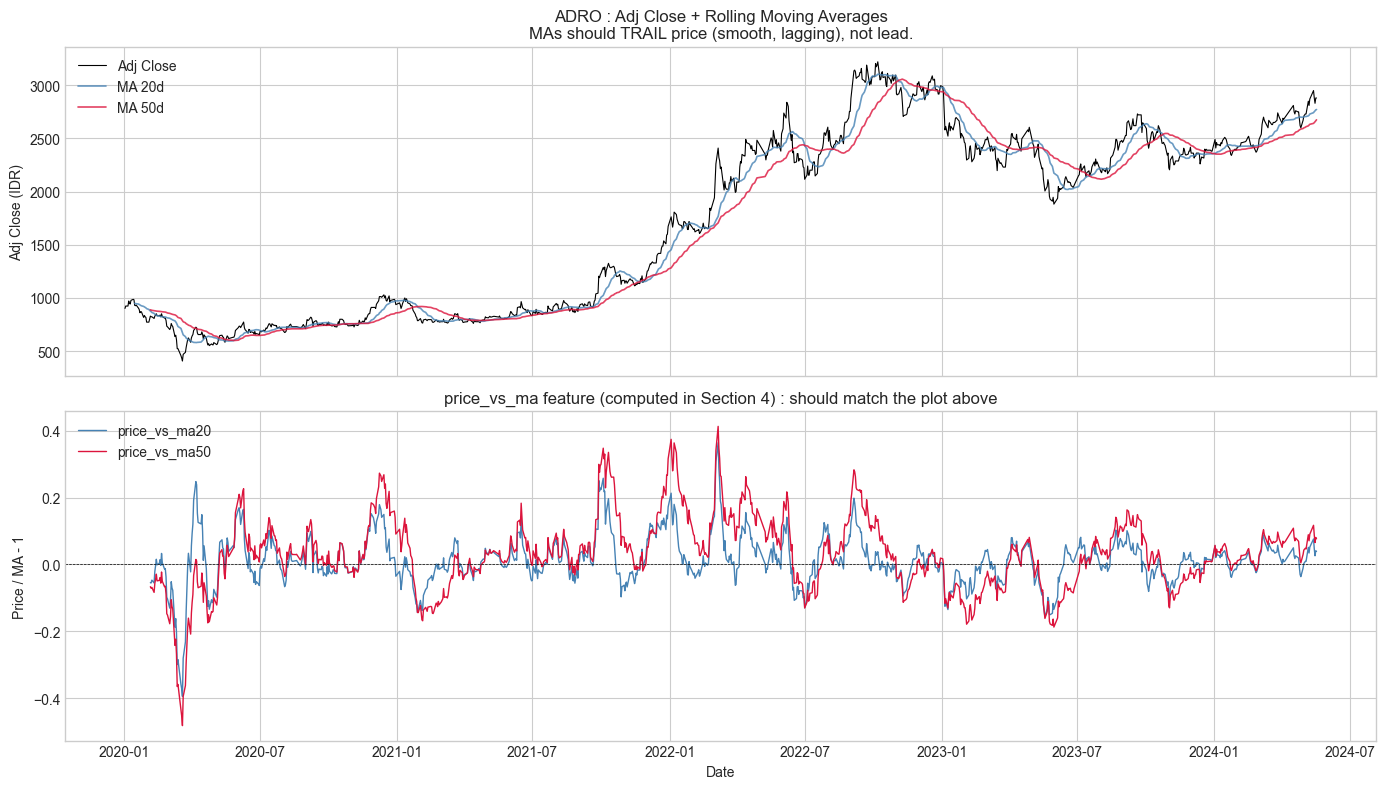

In [63]:
# Pick a ticker with enough history (no NaN in the rolling features)
sample_ticker = 'ADRO'
sample = df[df['Ticker'] == sample_ticker].copy()

# Compute rolling MAs directly for plotting (to verify our features match)
sample = sample.sort_values('Date')
sample['ma20'] = sample['Adj Close'].rolling(20, min_periods=10).mean()
sample['ma50'] = sample['Adj Close'].rolling(50, min_periods=25).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: price + rolling MAs
ax1.plot(sample['Date'], sample['Adj Close'], color='black', linewidth=0.8, label='Adj Close')
ax1.plot(sample['Date'], sample['ma20'], color='steelblue', linewidth=1.2, alpha=0.8, label='MA 20d')
ax1.plot(sample['Date'], sample['ma50'], color='crimson', linewidth=1.2, alpha=0.8, label='MA 50d')
ax1.set_ylabel('Adj Close (IDR)')
ax1.set_title(f'{sample_ticker} : Adj Close + Rolling Moving Averages\nMAs should TRAIL price (smooth, lagging), not lead.')
ax1.legend(loc='upper left')

# Bottom: price_vs_ma feature (should match (Close/MA - 1) from the plot above)
sample_valid = sample.dropna(subset=['price_vs_ma20', 'price_vs_ma50'])
ax2.plot(sample_valid['Date'], sample_valid['price_vs_ma20'], color='steelblue', linewidth=1, label='price_vs_ma20')
ax2.plot(sample_valid['Date'], sample_valid['price_vs_ma50'], color='crimson', linewidth=1, label='price_vs_ma50')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Price / MA - 1')
ax2.set_xlabel('Date')
ax2.set_title('price_vs_ma feature (computed in Section 4) : should match the plot above')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [64]:
# feature values should be consistent with the plot
print(f"Latest valid row for {sample_ticker}:")
latest = sample_valid.iloc[-1]
print(f"  Date: {latest['Date'].date()}")
print(f"  Adj Close / MA20 - 1 (manual): {latest['Adj Close'] / latest['ma20'] - 1:.6f}")
print(f"  price_vs_ma20 (feature): {latest['price_vs_ma20']:.6f}")

Latest valid row for ADRO:
  Date: 2024-05-17
  Adj Close / MA20 - 1 (manual): 0.039148
  price_vs_ma20 (feature): 0.039148


---
### Lag Shift Verification

Scatter plot of `daily_return(t)` vs `daily_return_lag1(t+1)`. If `shift(1)` works correctly, `daily_return_lag1` at row `t+1` should equal `daily_return` at row `t`. On a scatter plot, all points should lie on the line y=x. If they don't, the shift direction is wrong.

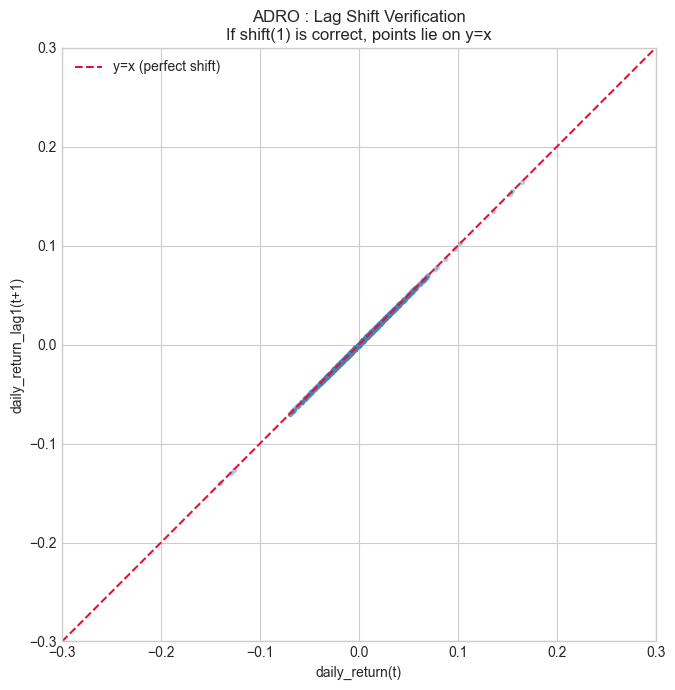

In [65]:
sub = df[df['Ticker'] == sample_ticker][['Date', 'daily_return', 'daily_return_lag1']].copy()

# If shift is correct: daily_return_lag1 at row t+1 = daily_return at row t
# So we plot: x = daily_return(t), y = daily_return_lag1(t+1) [i.e., shift y back by 1 to align]
sub['return_t'] = sub['daily_return']
sub['lag1_at_t_plus_1'] = sub['daily_return_lag1'].shift(-1)  # bring lag1(t+1) back to align with t

valid = sub.dropna(subset=['return_t', 'lag1_at_t_plus_1'])
# Sample 2000 points to avoid overplotting
sample_pts = valid.sample(min(2000, len(valid)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(sample_pts['return_t'], sample_pts['lag1_at_t_plus_1'], alpha=0.3, s=8, color='steelblue')
ax.plot([-0.3, 0.3], [-0.3, 0.3], color='crimson', linestyle='--', linewidth=1.5, label='y=x (perfect shift)')
ax.set_xlabel('daily_return(t)')
ax.set_ylabel('daily_return_lag1(t+1)')
ax.set_title(f'{sample_ticker} : Lag Shift Verification\nIf shift(1) is correct, points lie on y=x')
ax.legend()
ax.set_xlim(-0.3, 0.3)
ax.set_ylim(-0.3, 0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [66]:
# Numerical check: correlation should be ~1.0
corr = valid['return_t'].corr(valid['lag1_at_t_plus_1'])
print(f"Correlation between daily_return(t) and daily_return_lag1(t+1): {corr:.6f}")
print(f"(Should be ~1.0 — confirms shift(1) correctly grabbed yesterday's return)")

# Show a few rows to manually verify
print(f"\nManual verification (first 5 rows of {sample_ticker}):")
check = sub[['Date', 'daily_return', 'daily_return_lag1']].head(6).copy()
check['lag1_should_equal_prev_return'] = check['daily_return'].shift(1)
print(check.to_string(index=False))
print("Column 'daily_return_lag1' should equal 'lag1_should_equal_prev_return'")

Correlation between daily_return(t) and daily_return_lag1(t+1): 1.000000
(Should be ~1.0 — confirms shift(1) correctly grabbed yesterday's return)

Manual verification (first 5 rows of ADRO):
      Date  daily_return  daily_return_lag1  lag1_should_equal_prev_return
2020-01-02           NaN                NaN                            NaN
2020-01-03      0.024820                NaN                            NaN
2020-01-06      0.000000           0.024820                       0.024820
2020-01-07      0.051194           0.000000                       0.000000
2020-01-08     -0.022727           0.051194                       0.051194
2020-01-09     -0.006645          -0.022727                      -0.022727
Column 'daily_return_lag1' should equal 'lag1_should_equal_prev_return'


In [67]:
df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,sector,daily_return,...,dist_from_high20,dist_from_low20,price_vs_ma50,volatility_50d,volume_ratio_50d,volume_std_50d,momentum_50d,dist_from_high50,dist_from_low50,autocorr_20d
0,2020-01-13,ABMM,1300.0,1515.0,1300.0,1515.0,1214.466431,500.0,Energy,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-16,ABMM,1495.0,1495.0,1490.0,1490.0,1194.425781,1500.0,Energy,-0.016502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-20,ABMM,1490.0,1490.0,1490.0,1490.0,1194.425781,6000.0,Energy,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-23,ABMM,1475.0,1480.0,1470.0,1480.0,1186.409424,800.0,Energy,-0.006711,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-28,ABMM,1450.0,1450.0,1450.0,1450.0,1162.360596,100.0,Energy,-0.020270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95927,2024-05-13,ZYRX,149.0,149.0,144.0,146.0,146.000000,180100.0,Technology,-0.013514,...,-0.020134,0.013889,-0.053546,0.016606,0.681928,463044.590333,-0.098765,-0.109756,0.013889,-0.273934
95928,2024-05-14,ZYRX,146.0,146.0,142.0,146.0,146.000000,95800.0,Technology,0.000000,...,-0.020134,0.013889,-0.052071,0.016279,0.370580,463361.797642,-0.075949,-0.109756,0.013889,-0.299601
95929,2024-05-15,ZYRX,143.0,146.0,135.0,140.0,140.000000,3749200.0,Technology,-0.041096,...,-0.060403,0.000000,-0.088660,0.017084,11.334079,676561.599606,-0.125000,-0.146341,0.000000,-0.292394
95930,2024-05-16,ZYRX,141.0,141.0,138.0,139.0,139.000000,437800.0,Technology,-0.007143,...,-0.060811,0.000000,-0.092571,0.017049,1.303783,676406.617487,-0.136646,-0.152439,0.000000,-0.183682


---
## Section 5: Cross-Sectional & Sector Features

Instead of Technical Analysis Indicators (TA) which are just functions of the underlying price action, cross-sectional and sector features encodes new information about how a stock behaves relative to its sector peers. Unlike TA indicators, this cannot be derived from a single ticker's OHLCV history.

In [68]:
cross_features = []

# sector avg return / date (EXCLUDE SELF!!!!!!)
def sector_avg_excluding(group):
    """each ticker, compute sector mean return"""
    n = len(group)
    total = group.sum()
    # (total - self) / (n - 1); handle n==1 edge case
    return pd.Series(
        np.where(n > 1, (total - group.values) / (n - 1), np.nan),
        index=group.index
    )

In [69]:
df = df.sort_values(['Date', 'sector', 'Ticker']).reset_index(drop=True)

In [70]:
# group by Date + Sector
gs = df.groupby(['Date', 'sector'])

In [71]:
# sector average return 
df['sector_avg_return'] = gs['daily_return'].transform(sector_avg_excluding)

In [72]:
# sector return dispersion (std of returns across sector peers on same day)
df['sector_return_dispersion'] = gs['daily_return'].transform('std')

In [73]:
# relative strength: this stock vs its sector
df['relative_strength'] = df['daily_return'] - df['sector_avg_return']

In [74]:
# market breadth: fraction of sector peers with positive return
df['sector_pos_frac'] = gs['daily_return'].transform(
    lambda x: (x > 0).mean()
)

In [75]:
# sector volume trend: total sector volume today
df['sector_total_volume'] = gs['Volume'].transform('sum')

In [76]:
cross_features.extend([
    'sector_avg_return', 'sector_return_dispersion', 'relative_strength',
    'sector_pos_frac', 'sector_total_volume'
])

In [77]:
# rolling relative strength
for w in [5, 20]:
    col = f'rel_strength_ma{w}'
    df[col] = df.groupby('Ticker')['relative_strength'].transform(
        lambda x: x.rolling(w, min_periods=max(w // 2, 2)).mean()
    )
    cross_features.append(col)

In [78]:
# sector volume relative to its own 20-day rolling avg (per-sector)
for sector_name in df['sector'].unique():
    mask = df['sector'] == sector_name
    daily_vol = df.loc[mask, ['Date', 'sector_total_volume']].drop_duplicates()
    daily_vol = daily_vol.sort_values('Date')
    daily_vol['sector_vol_ma20'] = daily_vol['sector_total_volume'].rolling(20, min_periods=10).mean()
    daily_vol['sector_vol_ratio'] = daily_vol['sector_total_volume'] / daily_vol['sector_vol_ma20']
    mapper = daily_vol.set_index('Date')['sector_vol_ratio'].to_dict()
    df.loc[mask, 'sector_vol_regime'] = df.loc[mask, 'Date'].map(mapper)

In [79]:
cross_features.append('sector_vol_regime')

In [80]:
print(f"Cross-sectional features created: {len(cross_features)}")
print(f"  Features: {cross_features}")
print(f"\nSample sector stats (latest 5 days, Energy sector):")
energy_sample = df[df['sector'] == 'Energy'].drop_duplicates(['Date']).tail(5)
display_cols = ['Date'] + [c for c in cross_features if c in df.columns]
print(energy_sample[display_cols].to_string(index=False))

Cross-sectional features created: 8
  Features: ['sector_avg_return', 'sector_return_dispersion', 'relative_strength', 'sector_pos_frac', 'sector_total_volume', 'rel_strength_ma5', 'rel_strength_ma20', 'sector_vol_regime']

Sample sector stats (latest 5 days, Energy sector):
      Date  sector_avg_return  sector_return_dispersion  relative_strength  sector_pos_frac  sector_total_volume  rel_strength_ma5  rel_strength_ma20  sector_vol_regime
2024-05-13          -0.000928                  0.043260           0.024427         0.316456         2076404700.0          0.005412          -0.003312           0.788292
2024-05-14           0.001998                  0.030023          -0.007100         0.371795         3060414600.0          0.003280          -0.003376           1.131837
2024-05-15           0.006043                  0.045599          -0.057325         0.379747         3333266900.0         -0.009986          -0.005477           1.184458
2024-05-16           0.004661                  0

---
### Cross-Sectional Stock vs Sector Returns

For one date and one sector, visualize `relative_strength` = stock return − sector average return (ex-self).

Wide distribution = high cross-sectional dispersion that day (stocks moved independently); narrow distribution = macro/sector-driven day.

In [81]:
sample_date = pd.Timestamp('2024-05-15')
sector = 'Technology'
N_SAMPLE = 12

In [82]:
mask = (df['Date'] == sample_date) & (df['sector'] == sector)
day_slice = df[mask][['Ticker', 'daily_return', 'sector_avg_return', 'relative_strength']].dropna()
day_slice = day_slice.sort_values('relative_strength')

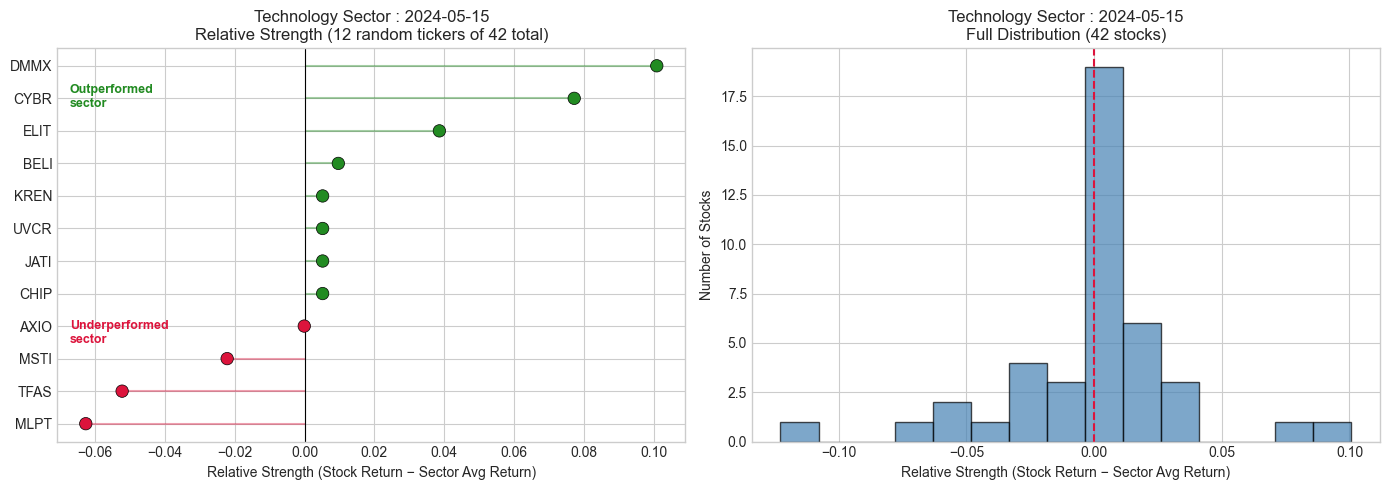

Technology sector on 2024-05-15 (42 stocks):
  Relative strength mean: -0.000000 (should be ~0 by construction)
  Relative strength std:  0.035954
  Range: [-0.1229, 0.1008]
  Outperformed sector: 27/42
  Underperformed:      15/42


In [83]:
# === LEFT 
rng = np.random.default_rng(42)
sample_tickers = rng.choice(day_slice['Ticker'].unique(), size=min(N_SAMPLE, len(day_slice)), replace=False)
sample_slice = day_slice[day_slice['Ticker'].isin(sample_tickers)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# dot = one stock's deviation from sector average
y_positions = range(len(sample_slice))
colors = ['forestgreen' if v > 0 else 'crimson' for v in sample_slice['relative_strength']]
ax1.hlines(y=y_positions, xmin=0, xmax=sample_slice['relative_strength'], 
           colors=colors, alpha=0.4, linewidth=1.5)
ax1.scatter(sample_slice['relative_strength'], y_positions, 
            c=colors, s=80, edgecolors='black', linewidth=0.5, zorder=3)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_yticks(y_positions)
ax1.set_yticklabels(sample_slice['Ticker'])
ax1.set_xlabel('Relative Strength (Stock Return − Sector Avg Return)')
ax1.set_title(f'{sector} Sector : {sample_date.date()}\nRelative Strength ({len(sample_slice)} random tickers of {len(day_slice)} total)')
ax1.annotate('Outperformed\nsector', xy=(0.02, 0.85), xycoords='axes fraction',
            fontsize=9, color='forestgreen', ha='left', fontweight='bold')
ax1.annotate('Underperformed\nsector', xy=(0.02, 0.25), xycoords='axes fraction', 
            fontsize=9, color='crimson', ha='left', fontweight='bold')

# === RIGHT
# histogram of ALL stocks in the sector
ax2.hist(day_slice['relative_strength'].dropna(), bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Relative Strength (Stock Return − Sector Avg Return)')
ax2.set_ylabel('Number of Stocks')
ax2.set_title(f'{sector} Sector : {sample_date.date()}\nFull Distribution ({len(day_slice)} stocks)')

plt.tight_layout()
plt.show()

print(f"{sector} sector on {sample_date.date()} ({len(day_slice)} stocks):")
print(f"  Relative strength mean: {day_slice['relative_strength'].mean():.6f} (should be ~0 by construction)")
print(f"  Relative strength std:  {day_slice['relative_strength'].std():.6f}")
print(f"  Range: [{day_slice['relative_strength'].min():.4f}, {day_slice['relative_strength'].max():.4f}]")
print(f"  Outperformed sector: {(day_slice['relative_strength'] > 0).sum()}/{len(day_slice)}")
print(f"  Underperformed:      {(day_slice['relative_strength'] < 0).sum()}/{len(day_slice)}")

---
## Section 6: Calendar Features

In [84]:
df['day_of_week'] = df['Date'].dt.dayofweek  # 0=Monday, 4=Friday
df['month'] = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter

calendar_features = ['day_of_week', 'month', 'quarter']

print("Calendar features added:", calendar_features)
print(f"\nDay-of-week distribution:")
print(df['day_of_week'].value_counts().sort_index())

Calendar features added: ['day_of_week', 'month', 'quarter']

Day-of-week distribution:
day_of_week
0    19333
1    19839
2    19167
3    18833
4    18760
Name: count, dtype: int64


---
## Section 7: Target Variable

`target = 1` if Close(t+1) > Close(t), else `0`. Computed per-ticker with `shift(-1)`. The last row of each ticker gets `NaN` target (no next day to observe) — this is expected and will be dropped in Section 8.

In [85]:
# compute target per ticker: 1 if Close(t+1) > Close(t), else 0
# Use np.where to explicitly set NaN where shift(-1) produces NaN (last row per ticker)
next_close = df.groupby('Ticker')['Close'].shift(-1)
df['target'] = np.where(
    next_close.isnull(),
    np.nan,
    (next_close > df['Close']).astype(int)
)

target_counts = df['target'].value_counts(normalize=True)
nan_targets = df['target'].isnull().sum()
print("Target distribution (excluding NaN):")
print(f"  Down/Flat (0): {target_counts.get(0, 0):.4f} ({target_counts.get(0, 0)*100:.1f}%)")
print(f"  Up (1):        {target_counts.get(1, 0):.4f} ({target_counts.get(1, 0)*100:.1f}%)")
print(f"  NaN:           {nan_targets:,} rows (expected: {df['Ticker'].nunique()} = one per ticker)")

sample_ticker = df['Ticker'].iloc[0]
sample = df[df['Ticker'] == sample_ticker].head(10).copy()
print(f"\nLeakage sanity check — {sample_ticker} (first 10 rows):")
print(sample[['Date', 'Close', 'target']].to_string(index=False))
print("  target=1 means Close(t+1) > Close(t) — verify manually above")
print("  Last row should have target=NaN")

Target distribution (excluding NaN):
  Down/Flat (0): 0.6482 (64.8%)
  Up (1):        0.3518 (35.2%)
  NaN:           130 rows (expected: 130 = one per ticker)

Leakage sanity check — ADRO (first 10 rows):
      Date  Close  target
2020-01-02 1495.0     0.0
2020-01-03 1465.0     0.0
2020-01-06 1465.0     1.0
2020-01-07 1540.0     0.0
2020-01-08 1505.0     0.0
2020-01-09 1495.0     1.0
2020-01-10 1550.0     1.0
2020-01-13 1565.0     0.0
2020-01-14 1560.0     0.0
2020-01-15 1475.0     0.0
  target=1 means Close(t+1) > Close(t) — verify manually above
  Last row should have target=NaN


---
### Verify labeling

In [89]:
next_close = df.groupby('Ticker')['Close'].shift(-1)
expected_target = (next_close > df['Close']).astype(int)

mask = df['target'].notna()
actual = df.loc[mask, 'target'].astype(int)
expected = expected_target[mask]

mismatches = actual != expected
n_total = len(actual)
n_mismatch = mismatches.sum()

print(f"Total rows verified: {n_total:,}")
print(f"Mismatches found:{n_mismatch:,} ({n_mismatch / n_total * 100:.4f}%)")

if n_mismatch > 0:
    print(f"\nSample mismatches:")
    mismatch_idx = mismatches[mismatches].index[:10]
    mismatch_df = df.loc[mismatch_idx, ['Date', 'Ticker', 'Close', 'target']].copy()
    mismatch_df['Close(t+1)'] = next_close[mismatch_idx]
    mismatch_df['expected'] = expected[mismatch_idx]
    print(mismatch_df.to_string(index=True))
else:
    print("\nLabel correct")

Total rows verified: 95,802
Mismatches found:0 (0.0000%)

Label correct


In [ ]:
# Replace inf/-inf from pct_change division-by-zero with NaN
# (occurs when prior-day Volume was 0; these will be dropped in Section 8)
inf_mask = np.isinf(df.select_dtypes(include=[np.number]))
inf_cols = inf_mask.any()
if inf_cols.any():
    inf_summary = inf_mask.sum()
    inf_summary = inf_summary[inf_summary > 0]
    print(f"Replacing inf values with NaN in {len(inf_summary)} columns:")
    for col, count in inf_summary.items():
        tickers = df.loc[inf_mask[col], 'Ticker'].unique()
        print(f"  {col}: {count} rows — tickers: {list(tickers)}")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    print(f"\nTotal inf values replaced: {inf_mask.sum().sum()}")
else:
    print("No inf values found.")

---
## Section 8: Drop NaN Rows

NaN sources: initial rolling windows (first ~50 days per ticker), shift operations (first row per ticker), and the final target row per ticker. We drop all rows with any NaN feature to keep the dataset clean.

In [91]:
before = len(df)
feature_cols = base_cols + lagged_features + rolling_features + cross_features + calendar_features
all_model_cols = feature_cols + ['target']

# consider columns that actually exist
all_model_cols = [c for c in all_model_cols if c in df.columns]

df_clean = df.dropna(subset=all_model_cols).copy()
after = len(df_clean)

print(f"Rows before NaN drop:  {before:>8,}")
print(f"Rows after NaN drop:   {after:>8,}")
print(f"Rows dropped:           {before - after:>8,} ({(before - after) / before * 100:.1f}%)")

# ticker: how many rows remain?
ticker_survival = df_clean.groupby('Ticker').size()
print(f"\nTicker row counts after NaN drop:")
print(f"  Min:    {ticker_survival.min():,}")
print(f"  Median: {ticker_survival.median():.0f}")
print(f" Max:    {ticker_survival.max():,}")

low_history = ticker_survival[ticker_survival < 252]
if len(low_history) > 0:
    print(f"\nckers with <252 rows (~1 year): {len(low_history)}")
    for t, n in low_history.items():
        print(f"    {t}: {n} rows")
else:
    print(f"\nAll tickers have >=252 rows — no tickers need removal.")

# veify no NaN remains
remaining_nan = df_clean[all_model_cols].isnull().sum().sum()
print(f"\nRemaining NaN values: {remaining_nan}")

Rows before NaN drop:    95,932
Rows after NaN drop:     84,072
Rows dropped:             11,860 (12.4%)

Ticker row counts after NaN drop:
  Min:    4
  Median: 792
 Max:    1,007

ckers with <252 rows (~1 year): 23
    ALII: 5 rows
    ARTI: 107 rows
    AWAN: 197 rows
    CBRE: 89 rows
    CGAS: 19 rows
    CHIP: 236 rows
    CNKO: 28 rows
    CUAN: 198 rows
    CYBR: 130 rows
    ENVY: 133 rows
    HILL: 228 rows
    HUMI: 128 rows
    IOTF: 89 rows
    IRSX: 158 rows
    JATI: 121 rows
    MAHA: 140 rows
    MENN: 197 rows
    MKAP: 4 rows
    MSTI: 66 rows
    RGAS: 66 rows
    RMKO: 136 rows
    TOSK: 5 rows
    TRON: 223 rows

Remaining NaN values: 0


---
## Section 9: Export Full Feature Engineered Dataset (Pre-Split, Per Sector)

- `Dataset/processed/energy.parquet` 
- `Dataset/processed/technology.parquet` 

Columns: Date, Ticker, Open, High, Low, Close, Adj Close, Volume, sector, all engineered features, target.

In [93]:
feature_cols_final = [c for c in feature_cols if c in df_clean.columns]
export_cols = ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] + feature_cols_final + ['target']

total_rows = 0
sector_sizes = {}

for sector in sorted(df_clean['sector'].unique()):
    mask = df_clean['sector'] == sector
    sector_df = df_clean[mask][export_cols].copy()
    sector_name = sector.lower()
    path = os.path.join(OUTPUT_DIR, f'{sector_name}.parquet')

    sector_df.to_parquet(path, index=False, compression='snappy')

    size_mb = os.path.getsize(path) / (1024**2)
    n_tickers = sector_df['Ticker'].nunique()
    sector_sizes[sector] = {'rows': len(sector_df), 'tickers': n_tickers, 'size_mb': size_mb}
    total_rows += len(sector_df)

    tc = sector_df['target'].value_counts()
    print(f"  {sector:<12} {n_tickers:>3} tickers  {len(sector_df):>8,} rows  {size_mb:>6.1f} MB  "
          f"target 0={tc.get(0,0):,} 1={tc.get(1,0):,}")

print(f"\nTotal: {total_rows:,} rows across {len(sector_sizes)} sectors → {OUTPUT_DIR}/")

feature_final_list = [c for c in feature_cols_final if c in df_clean.columns]
col_ref = pd.DataFrame({
    'column': (['Date', 'Ticker', 'sector', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
               + feature_final_list + ['target']),
    'group': (['metadata'] * 3 + ['ohlcv'] * 6 + ['feature'] * len(feature_final_list) + ['target'])
})
col_ref.to_csv(os.path.join(OUTPUT_DIR, 'feature_reference.csv'), index=False)
print(f"feat reference saved: {os.path.join(OUTPUT_DIR, 'feature_reference.csv')} ({len(feature_final_list)} features)")

  Energy        82 tickers    58,439 rows    24.4 MB  target 0=36,027 1=22,412
  Technology    44 tickers    25,633 rows    10.7 MB  target 0=16,527 1=9,106

Total: 84,072 rows across 2 sectors → Dataset\processed/
feat reference saved: Dataset\processed\feature_reference.csv (77 features)
